## Data Exploration

**Purpose:** Summarize the TBHubbard table used in the thesis: define on-site **U** and inter-site **V**, inspect data quality, and do exploratory analysis(distributions, Pearson correlations, and scatter diagnostics).

**Inputs:** `../data/tbhubbard_database.csv` (see `data/README.md` for provenance and citations).

**Outputs:** Figures and short takeaways that motivate preprocessing (group split, IQR outliers, `V` cutoff) and modeling choices (linear **U**, non-linear **V**).


In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 20

# Load and align naming with previous notebooks
raw_df = pd.read_csv('../data/tbhubbard_database.csv')
df = raw_df.rename(columns={
    'index_element': 'index_i',
    'element': 'atom_i',
    'ddec_charge_element': 'ddec_charge_i',
    'index_neighbor': 'index_j',
    'element_neighbor': 'atom_j',
    'ddec_charge_neighbor': 'ddec_charge_j',
})

for col in ['atom_i', 'atom_j']:
    df[col] = df[col].astype(str).str.replace(r'^(O|N)\d+$', r'\1', regex=True)

print('Rows:', len(df))
print('Unique materials (qmof_id):', df['qmof_id'].nunique())
df.head()

Rows: 464509
Unique materials (qmof_id): 242


,qmof_id,reduced_chemical_formula,full_chemical_formula,pld,lcd,density,volume,symmetry,index_i,atom_i,ddec_charge_i,index_j,atom_j,ddec_charge_j,distance,V
0,qmof-0091bbc,H7C7N1S1Cu1Br1,H28C28N4S4Cu4Br4,3.81269,4.56236,1.592058,1170.896444,P2_1/c_14_monoclinic_2/m,1,Cu,0.23439,1,Cu,0.234390,0.000000,13.2713
1,qmof-0091bbc,H7C7N1S1Cu1Br1,H28C28N4S4Cu4Br4,3.81269,4.56236,1.592058,1170.896444,P2_1/c_14_monoclinic_2/m,1,Cu,0.23439,5,S,-0.297568,4.262269,0.0760
2,qmof-0091bbc,H7C7N1S1Cu1Br1,H28C28N4S4Cu4Br4,3.81269,4.56236,1.592058,1170.896444,P2_1/c_14_monoclinic_2/m,1,Cu,0.23439,7,S,-0.297531,4.519819,0.3200
3,qmof-0091bbc,H7C7N1S1Cu1Br1,H28C28N4S4Cu4Br4,3.81269,4.56236,1.592058,1170.896444,P2_1/c_14_monoclinic_2/m,1,Cu,0.23439,1595,Br,-0.389887,4.676169,-0.6150
4,qmof-0091bbc,H7C7N1S1Cu1Br1,H28C28N4S4Cu4Br4,3.81269,4.56236,1.592058,1170.896444,P2_1/c_14_monoclinic_2/m,1,Cu,0.23439,9,Br,-0.389836,4.704777,-0.5561


### Schema and data quality

Inspect column names, dtypes, missing counts, and a small random sample before building the **U** and **V** subsets.


In [55]:
# Columns, dtypes, missing values, sample
print("Columns:")
display(df.columns.to_series())

print("\nData types:")
display(df.dtypes)

print("\nSample rows:")
display(df.sample(5, random_state=100))

print("\nMissing values (columns with any NaN):")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])


Columns:


qmof_id                                      qmof_id
reduced_chemical_formula    reduced_chemical_formula
full_chemical_formula          full_chemical_formula
pld                                              pld
lcd                                              lcd
density                                      density
volume                                        volume
symmetry                                    symmetry
index_i                                      index_i
atom_i                                        atom_i
ddec_charge_i                          ddec_charge_i
index_j                                      index_j
atom_j                                        atom_j
ddec_charge_j                          ddec_charge_j
distance                                    distance
V                                                  V
dtype: object


Data types:


qmof_id                      object
reduced_chemical_formula     object
full_chemical_formula        object
pld                         float64
lcd                         float64
density                     float64
volume                      float64
symmetry                     object
index_i                       int64
atom_i                       object
ddec_charge_i               float64
index_j                       int64
atom_j                       object
ddec_charge_j               float64
distance                    float64
V                           float64
dtype: object


Sample rows:


,qmof_id,reduced_chemical_formula,full_chemical_formula,pld,lcd,density,volume,symmetry,index_i,atom_i,ddec_charge_i,index_j,atom_j,ddec_charge_j,distance,V
450879,qmof-f848b6b,H8C36O16F12Zr3,H16C72O32F24Zr6,3.48933,8.76753,1.126618,3531.771769,F222_22_orthorhombic_222,12,O,-0.619910,13,O,-0.619962,7.312968,0.3534
243383,qmof-8955ecc,H16C25O16Hf3,H32C50O32Hf6,14.38163,14.91243,0.777340,4733.156695,P1_1_triclinic_1,20,O,-0.941341,1696,O,-1.036833,17.777197,-0.0128
345430,qmof-b923499,H14C26O16Hf3,H28C52O32Hf6,15.92349,17.33330,0.644045,5764.295593,P1_1_triclinic_1,14,O,-0.926439,2748,O,-1.081113,10.568276,0.0049
64400,qmof-19945d1,H15C31O29Zr3,H30C62O58Zr6,3.54512,5.38047,1.642060,2275.533955,P1_1_triclinic_1,25,O,-0.604169,33,O,-1.076961,5.169664,0.1976
27869,qmof-0bbf75f,H13C13N1O16Zr3,H52C52N4O64Zr12,8.69717,10.37999,0.853018,5551.191521,P1_1_triclinic_1,43,O,-0.928850,4104,O,-0.832522,23.531758,-0.0020



Missing values (columns with any NaN):


Series([], dtype: int64)

### Build **U** and **V** subsets 

- **U (on-site):** rows with `distance == 0`; drop `atom_j`, `ddec_charge_j`, and `distance`; rename `V` → `U`.
- **V (inter-site):** rows with `distance != 0`; keep both sites and `distance`; target remains `V`.

One observation per on-site interaction for **U**, and one per atom pair for **V** (~460k pair rows across 242 MOFs).


In [56]:
# Build U and V interaction datasets (keep qmof_id for grouping)

# U: on-site Hubbard => distance == 0
df_u = df[df['distance'] == 0].copy()
df_u = df_u.drop(columns=['distance', 'ddec_charge_j', 'atom_j'])
df_u = df_u.rename(columns={'V': 'U'})

# V: hopping => distance != 0
df_v = df[df['distance'] != 0].copy()
df_v['atom_pair'] = df_v['atom_i'] + '-' + df_v['atom_j']

# Keep only the columns used in the original regression design
df_u = df_u[['qmof_id', 'pld', 'lcd', 'density', 'volume', 'ddec_charge_i', 'atom_i', 'U']].copy()
df_v = df_v[['qmof_id', 'pld', 'lcd', 'density', 'volume', 'ddec_charge_i', 'ddec_charge_j', 'distance', 'atom_i', 'atom_j', 'V', 'atom_pair']].copy()

print('U rows (distance=0):', len(df_u))
print('V rows (distance!=0):', len(df_v))
print('Unique qmof_id in U:', df_u['qmof_id'].nunique())
print('Unique qmof_id in V:', df_v['qmof_id'].nunique())

U rows (distance=0): 9617
V rows (distance!=0): 454892
Unique qmof_id in U: 242
Unique qmof_id in V: 242


### Target distributions

Histograms for **U** and **V** (eV). 

- U present values between 0 and 10 eV
- V is caracterized by small values, with a large concentration around 0 eV. 


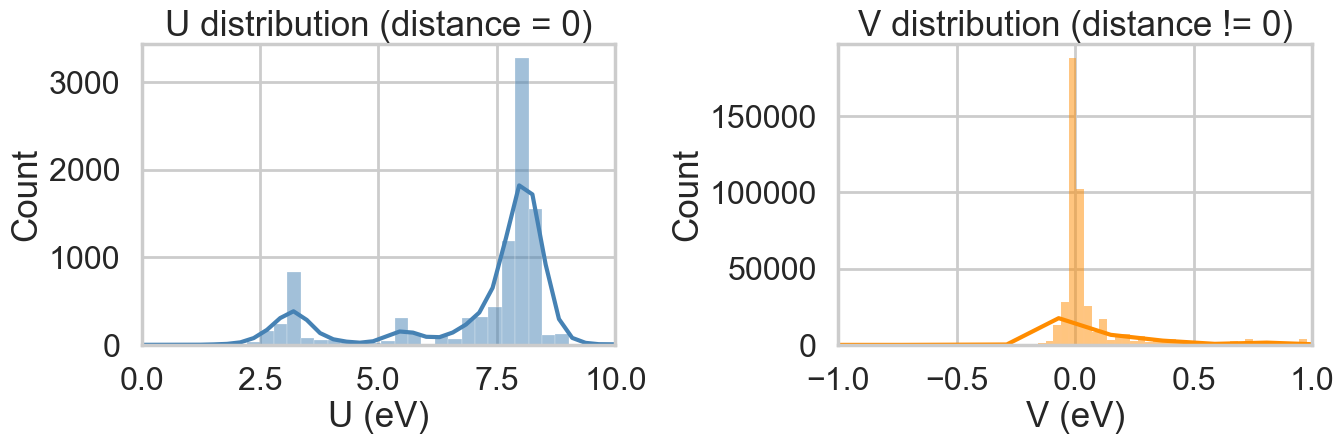

In [62]:
# Basic distributions for targets
sns.set_context("poster", font_scale=1.05)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_u['U'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('U distribution (distance = 0)')
axes[0].set_xlabel('U (eV)')
axes[0].set_xlim(0, 10)

sns.histplot(df_v['V'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('V distribution (distance != 0)')
axes[1].set_xlabel('V (eV)')
axes[1].set_xlim(-1, 1)

plt.tight_layout()
plt.show()

### Pearson correlation heatmaps (numeric descriptors)

- **high correlation within the structural block** (`pld`, `lcd`, `density`, `volume`) - possible multicollinearity

- **weak linear association** between that block and the targets **U**/**V**.

- **U** correlates more with **charge on site i**

- **V** correlates strongly with **inter-site distance** 


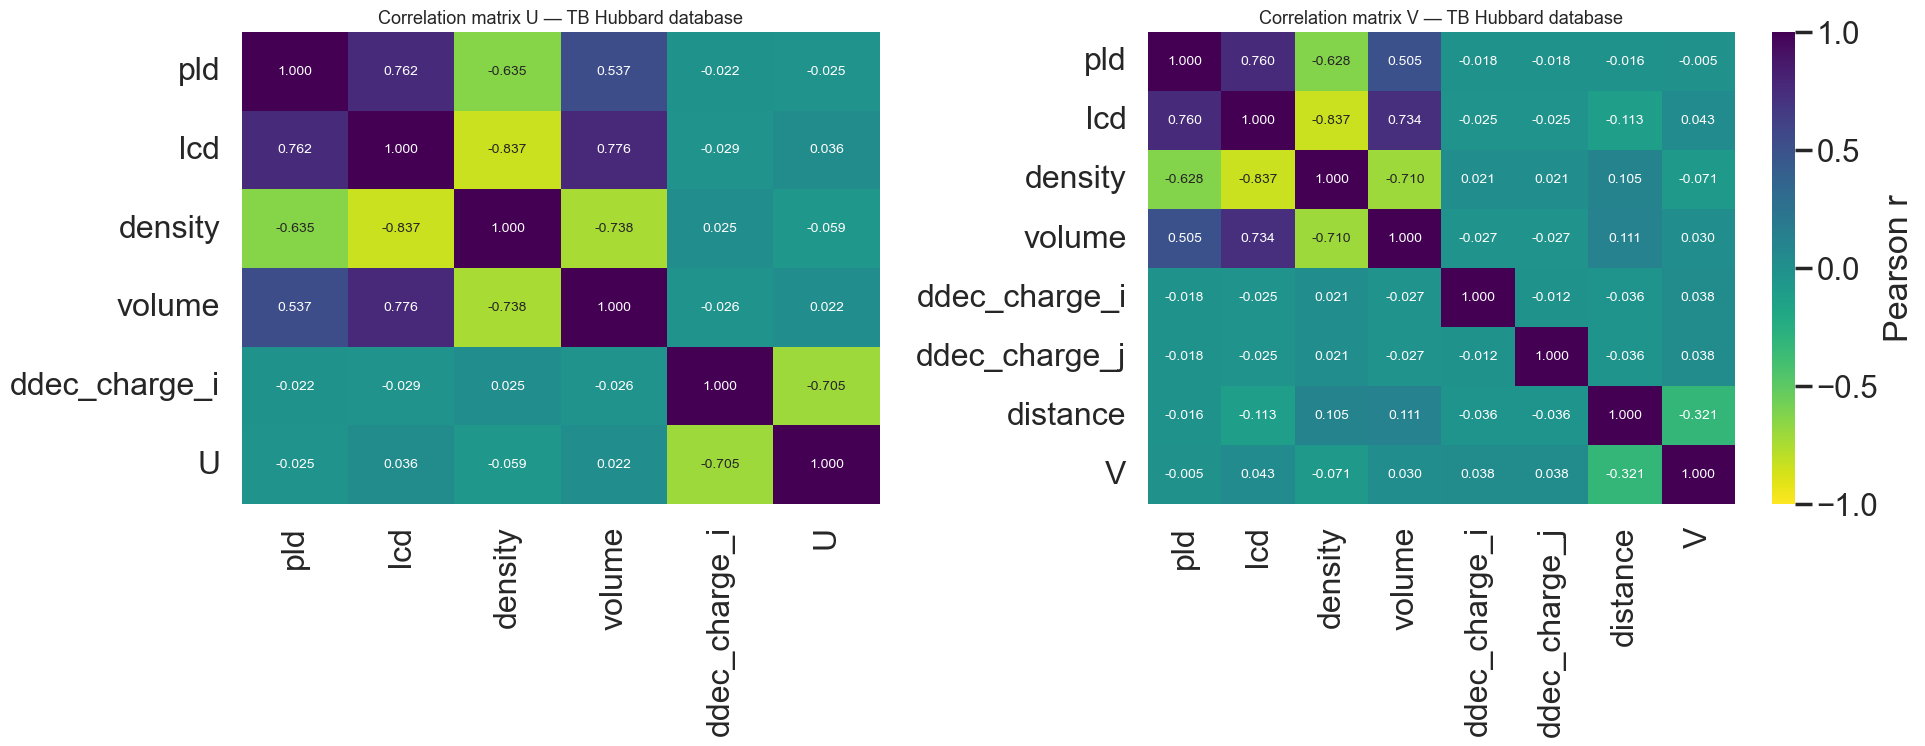

In [63]:
# Correlation matrix (numeric variables only; element dummies omitted for readability)
numerical_cols_u = df_u.select_dtypes(include=['number']).columns

numerical_cols_v = df_v.select_dtypes(include=['number']).columns


correlation_matrix_u = df_u[numerical_cols_u].corr()
correlation_matrix_v = df_v[numerical_cols_v].corr()



# Heatmap of correlations
fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={"width_ratios": [1, 1.15]})

sns.set_context("poster", font_scale=1.02)


sns.heatmap(correlation_matrix_u, annot=True, fmt=".3f",
            cmap=plt.cm.viridis_r, annot_kws={'size': 10},
            vmin=-1, vmax=1, ax=axes[0],  cbar=False)
axes[0].set_title('Correlation matrix U — TB Hubbard database', fontsize=13)

sns.heatmap(correlation_matrix_v, annot=True, fmt=".3f",
            cmap=plt.cm.viridis_r, annot_kws={'size': 10},
            vmin=-1, vmax=1, ax=axes[1],
            cbar_kws={"label": "Pearson r"})
axes[1].set_title('Correlation matrix V — TB Hubbard database', fontsize=13)

plt.tight_layout()
plt.show()

### Distributions by chemical identity (thesis-style boxplots)

- Unbalanced dataset with large concentration of O, Zr, N and Hf, compared to other elements. 

- Large outliers for some elements (e.g. Cu), which might limit generalization


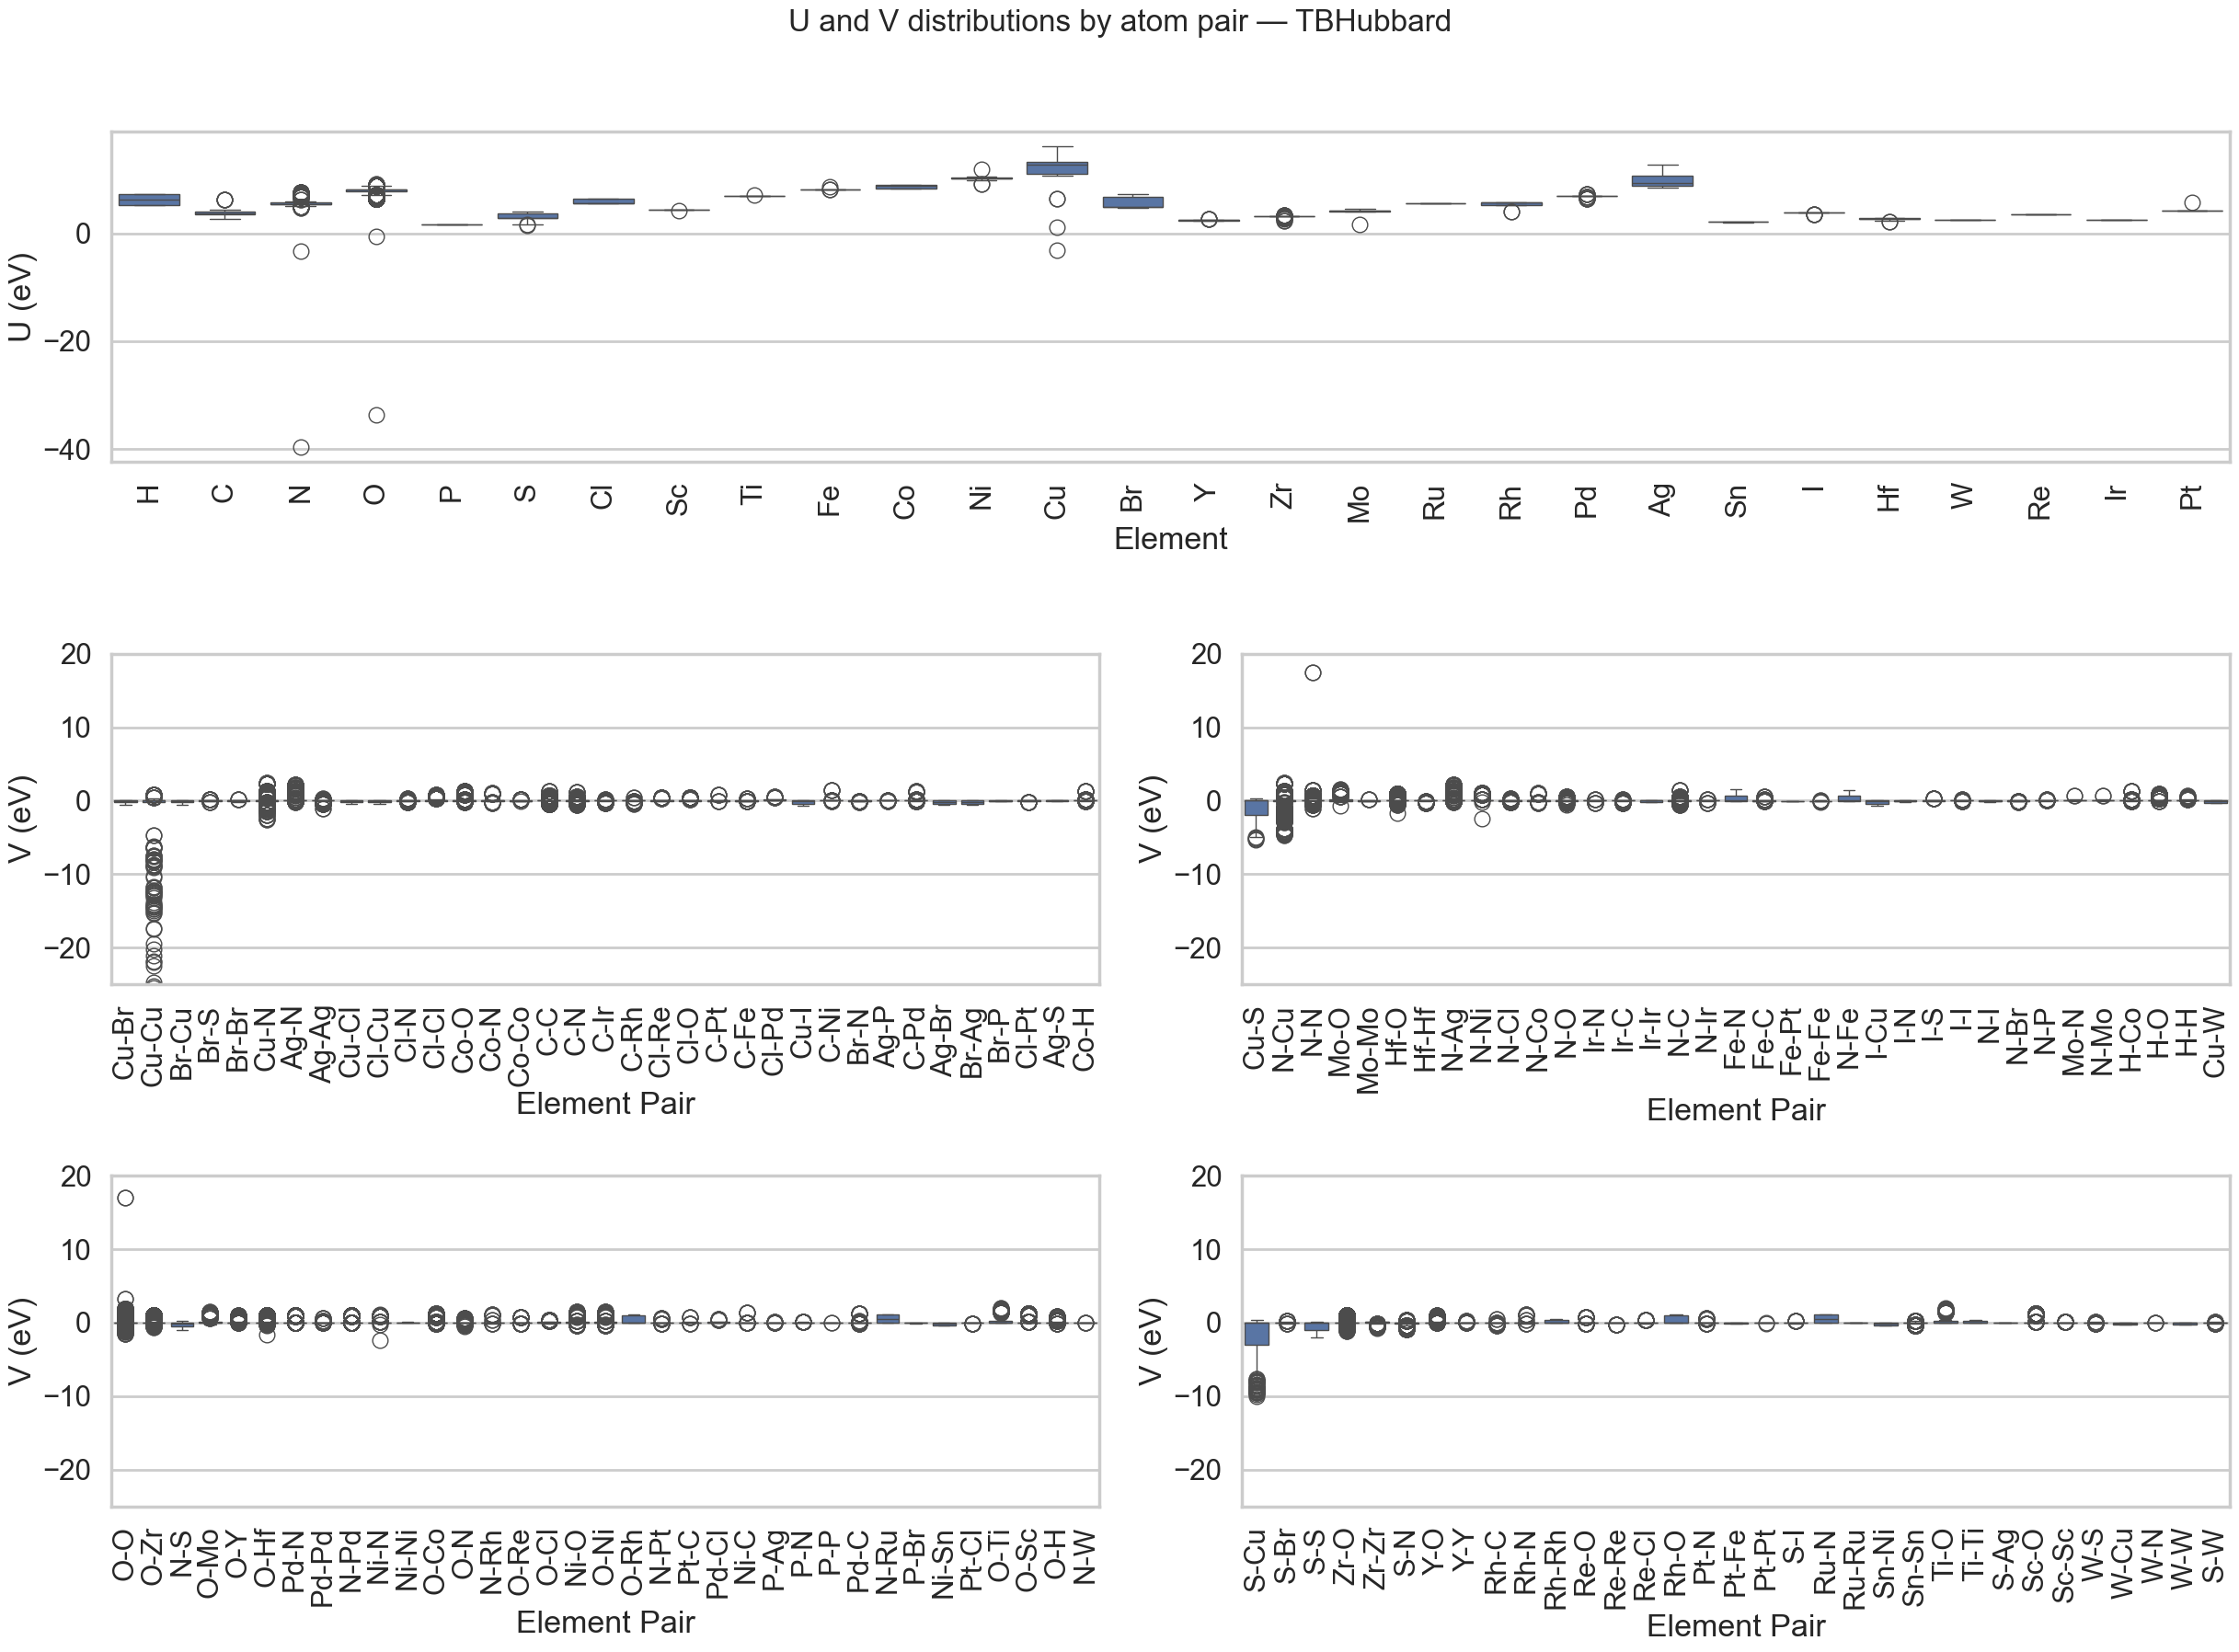

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from pymatgen.core import Element

fig = plt.figure(figsize=(25, 18))
gs = GridSpec(3, 2, figure=fig)
plt.rcParams['font.size'] = 28

sorted_atoms = sorted(df_u['atom_i'].unique(), key=lambda e: Element(e).Z)


# --- Row 1: df_u spanning both columns ---
ax_u = fig.add_subplot(gs[0, :])
sns.boxplot(data=df_u, x='atom_i', y='U', ax=ax_u, order=sorted_atoms)
ax_u.tick_params(axis='x', rotation=90)
ax_u.set_xlabel('Element')
ax_u.set_ylabel('U (eV)')
# ax_u.set_title('U by atom_i')

# --- Rows 2-3: df_v split into 4 panels ---
atoms = sorted(df_v['atom_pair'].unique())
n_atoms = len(atoms)
chunk_size = int(np.ceil(n_atoms / 4))
chunks = [atoms[i:i+chunk_size] for i in range(0, n_atoms, chunk_size)]

positions = [gs[1, 0], gs[1, 1], gs[2, 0], gs[2, 1]]

for pos, atom_subset in zip(positions, chunks):
    ax = fig.add_subplot(pos)
    mask = df_v['atom_pair'].isin(atom_subset)
    sns.boxplot(data=df_v.loc[mask], x='atom_pair', y='V', ax=ax)
    ax.tick_params(axis='x', rotation=90)
    ax.set_xlabel('Element Pair')
    ax.set_ylabel('V (eV)')
    ax.set_ylim(-25,20)

plt.suptitle('U and V distributions by atom pair — TBHubbard', fontsize=24, y=1.01)
plt.tight_layout()
plt.show()

### Scatter plots 

 **U** clusters by element while **V** shows a clearer trend with **distance** (non-linear), so a linear model is plausible for **U** but weak for **V**.


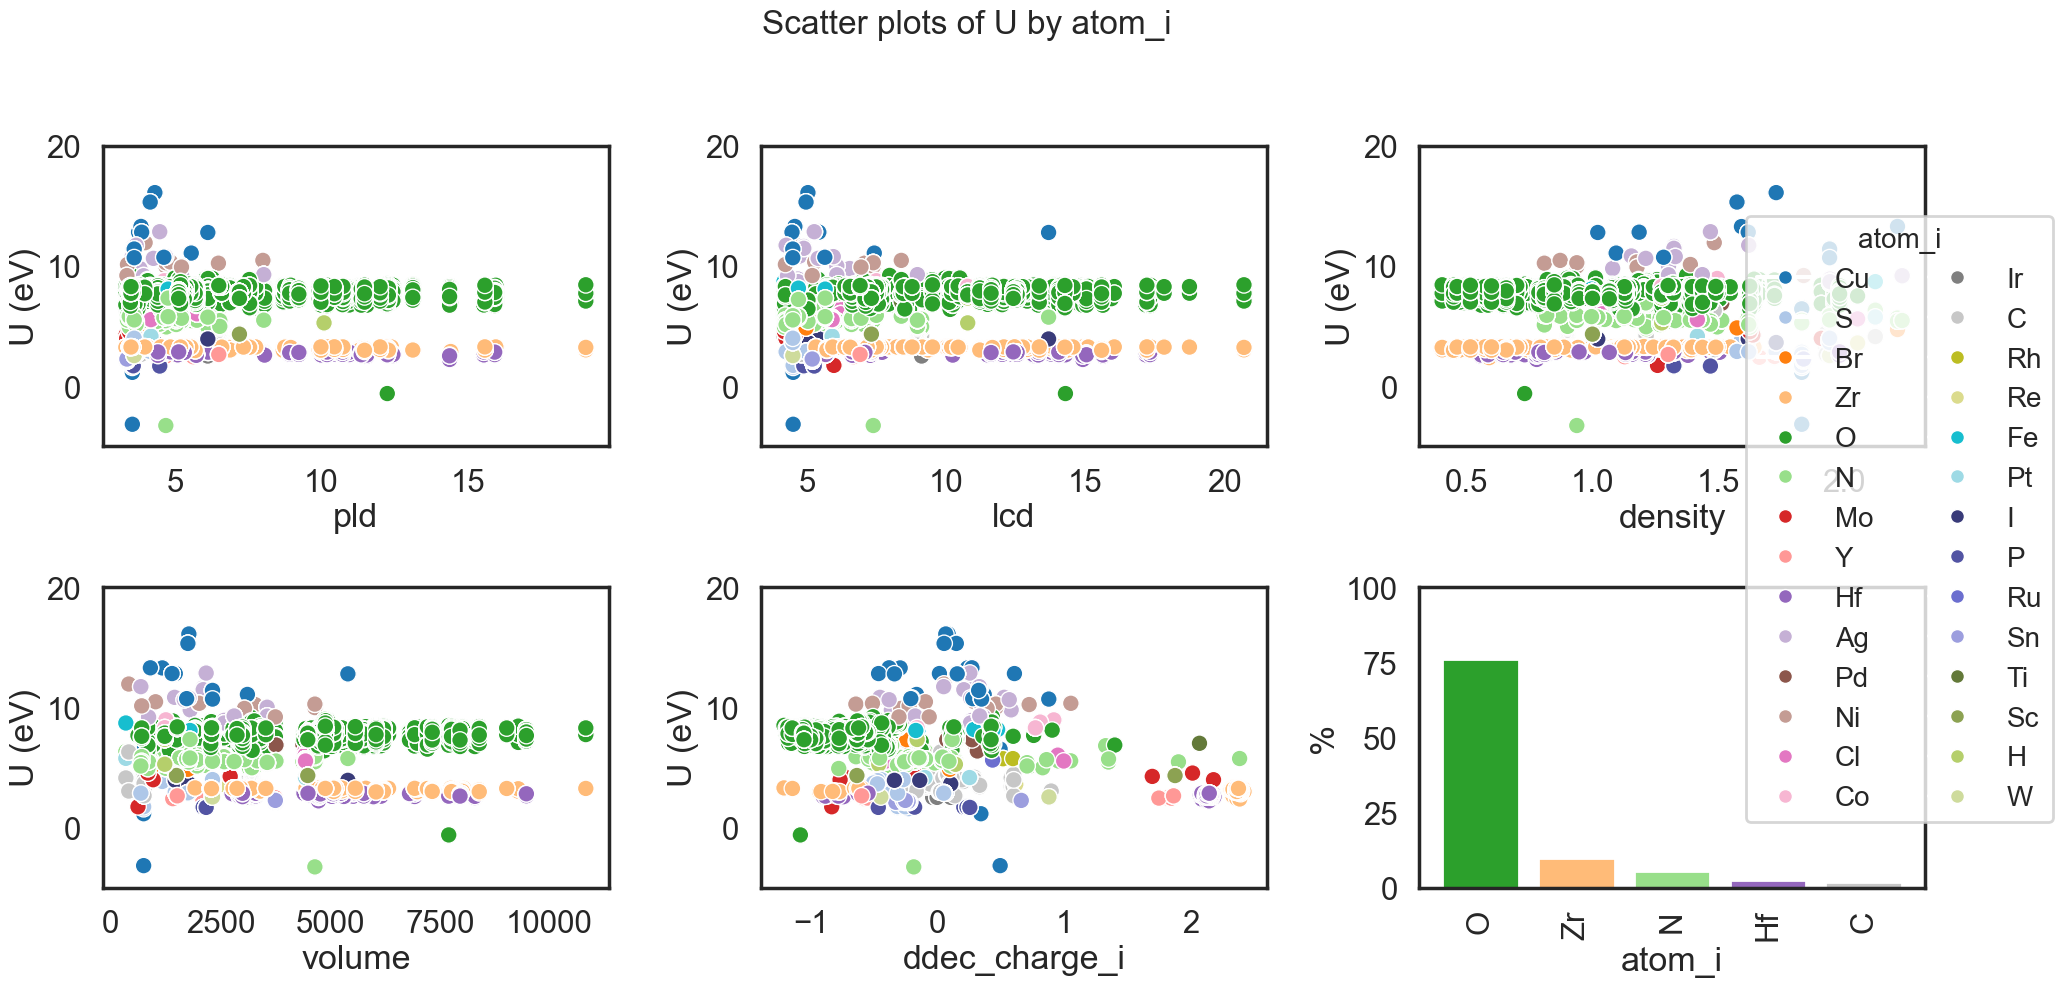

In [67]:
plt.rcParams['font.size'] = 28
sns.set_style("white")
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

features = ['pld', 'lcd', 'density', 'volume', 'ddec_charge_i']

atoms = df_u['atom_i'].unique()
palette = (sns.color_palette("tab20", 20) + 
           sns.color_palette("tab20b", 20) + 
           sns.color_palette("tab20c", 20))[:len(atoms)]
color_map = dict(zip(atoms, palette))


for ax, col in zip(axes.flat, features):
    sns.scatterplot(data=df_u, x=col, y='U', hue='atom_i', ax=ax,
                    palette=palette, legend=False)
    ax.set_xlabel(col)
    ax.set_ylim(-5, 20)
    ax.set_ylabel('U (eV)')

# 6th subplot: histogram of atom_i counts
hist_ax = axes[1, 2]
atom_counts = df_u['atom_i'].value_counts()
atom_pct = atom_counts / atom_counts.sum() * 100
atom_counts = atom_counts[atom_pct > 1]
atom_pct = atom_pct[atom_pct > 1]

hist_ax.bar(range(len(atom_counts)), atom_pct.values,
            color=[color_map[a] for a in atom_counts.index])
hist_ax.set_xticks(range(len(atom_counts)))
hist_ax.set_xticklabels(atom_counts.index, rotation=90)
hist_ax.set_xlabel('atom_i')
hist_ax.set_ylabel('%')
hist_ax.set_ylim(0, 100)
hist_ax.grid(False)

# Legend outside on the right
handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=color_map[atom], markersize=10, label=atom)
           for atom in atoms]

fig.legend(handles=handles, loc='center right', ncol=2, title='atom_i',
           frameon=True, fontsize=20, title_fontsize=20,
           bbox_to_anchor=(1.05, 0.5))
fig.suptitle('Scatter plots of U by atom_i', fontsize=24, y=1.01)
plt.tight_layout()
plt.show()

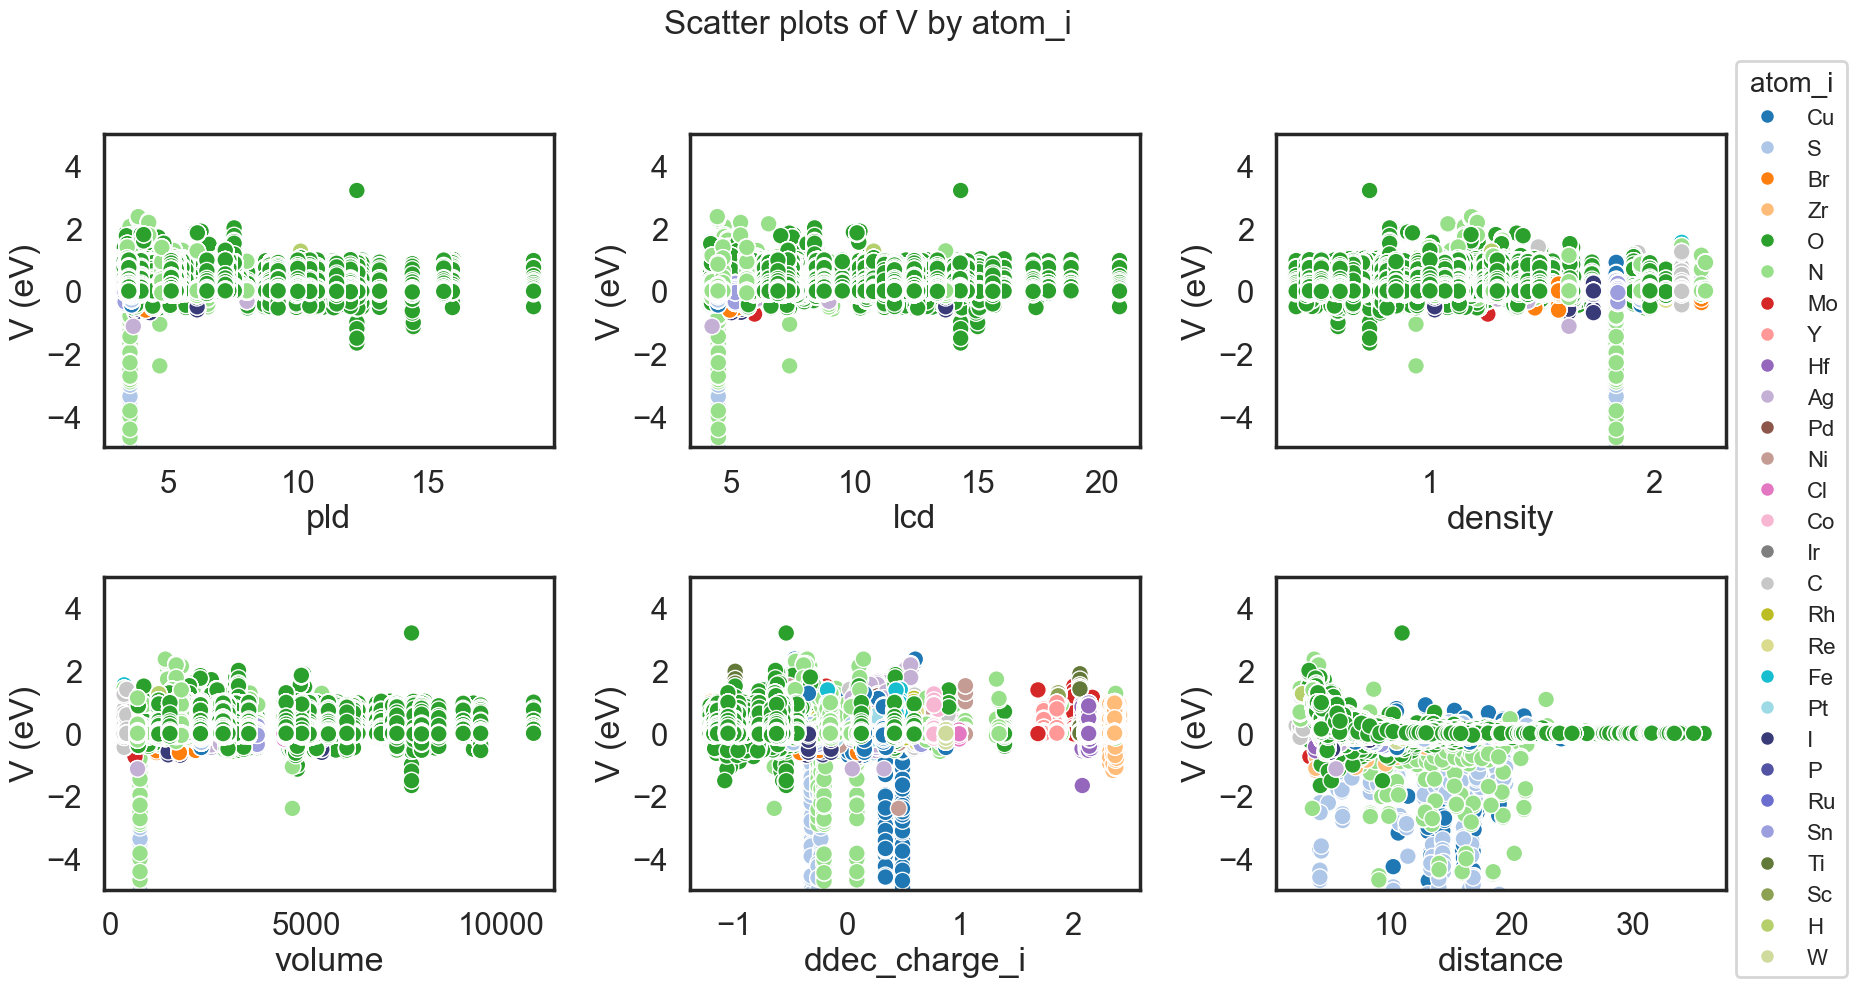

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features = ['pld', 'lcd', 'density', 'volume', 'ddec_charge_i', 'distance']

atoms = df_v['atom_i'].unique()
palette = (sns.color_palette("tab20", 20) + 
           sns.color_palette("tab20b", 20) + 
           sns.color_palette("tab20c", 20))[:len(atoms)]
color_map = dict(zip(atoms, palette))

for ax, col in zip(axes.flat, features):
    sns.scatterplot(data=df_v, x=col, y='V', hue='atom_i', ax=ax,
                    palette=palette, legend=False)
    ax.set_xlabel(col)
    ax.set_ylim(-5, 5)
    ax.set_ylabel('V (eV)')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=color_map[atom], markersize=10, label=atom)
           for atom in atoms]

fig.legend(handles=handles, loc='center right', ncol=1, title='atom_i',
           frameon=True, fontsize=16, title_fontsize=20,
           bbox_to_anchor=(1.05, 0.5))

fig.suptitle('Scatter plots of V by atom_i', fontsize=24, y=1.01)

plt.tight_layout()
plt.show()

### Summarized conclusions

1. **Scale and structure:** ~464k pair-level rows over **242 MOFs**; **U** is a small on-site subset; **V** dominates row count.

2. **Structural block:** `pld`, `lcd`, `density`, and `volume` are mutually correlated; they are **not** the main linear drivers of **U**/**V** in the exploratory analysis — **chemical identity** and **local** quantities matter more.

3. **U:** Values group strongly by **`atom_i`** (chemical identity is the main determinant of on-site **U**). Expect a strong **linear** model after dummy encoding, with caveats for rare / outlier-prone elements (e.g. Cu, Br in the discussion).

4. **V:** Strong visual link to **`distance`** and to the **i–j** pair type; behavior is **not** well captured by a single linear trend 

5. **Next steps in this repo:** `02_preprocessing.ipynb` (material-level split, IQR, `V` cutoff, VIF/`lcd` drop) → `03_modeling.ipynb` → `04_results_evaluation.ipynb`.
